In [ ]:
pip install xgboost

In [1]:
import pandas as pd

df = pd.read_csv("/Users/kaviraj/Desktop/GUVI/Project3/classification/c_encoded_dataset.csv")

df

,appointment_time,no_show,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,...,gender_M,disability_intellectual,disability_motor,appointment_shift_morning,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,17,1,9.0,1,0,1,23.18,0.00,27.5,0.0,...,False,True,False,False,False,False,False,False,False,True
1,7,0,11.0,1,0,1,14.31,0.02,16.5,0.6,...,True,True,False,True,False,False,False,False,False,True
2,16,0,8.0,1,0,1,21.61,0.01,29.9,0.2,...,True,True,False,False,False,False,False,False,False,True
3,14,1,9.0,1,0,1,21.39,0.11,24.1,1.4,...,True,True,False,False,False,False,False,False,False,True
4,8,0,12.0,0,0,0,20.15,0.02,23.1,0.2,...,True,False,True,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109552,16,1,18.0,0,0,0,18.97,0.00,25.6,0.2,...,True,True,False,False,False,False,False,False,True,False
109553,9,1,18.0,0,0,0,24.46,0.23,31.4,8.7,...,False,False,True,True,False,False,False,False,True,False
109554,13,0,8.0,1,0,1,20.88,0.00,23.8,5.1,...,False,True,False,False,False,False,False,False,True,False
109555,8,0,7.0,1,0,1,24.89,0.00,28.8,0.0,...,False,False,True,True,False,False,False,False,True,False


# 1. Feature & Target

In [2]:
X = df.drop('no_show', axis=1)
y = df['no_show']

# 2. Split Train & Test

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(87645, 38)
(21912, 38)


# 3. Without Scaling 
    - Logistic Regression
    - Desicion Tree
    - Random Forest Classifier
    - XGBoost Classifier

In [4]:
# 1. Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# model = LogisticRegression(max_iter = 1000) # The maximum number of iterations was increased to ensure convergence of the Logistic Regression optimization algorithm
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
model.fit(X_train, y_train) # pattern learning of a model happens here

y_pred_lr = model.predict(X_test) # prediction

# Evaluate
print("Logistic Regression Classifier Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test,y_pred_lr)) 
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Classifier Evaluation:
Accuracy: 0.613179992698065
              precision    recall  f1-score   support

           0       0.76      0.64      0.69     14952
           1       0.42      0.56      0.48      6960

    accuracy                           0.61     21912
   macro avg       0.59      0.60      0.59     21912
weighted avg       0.65      0.61      0.62     21912

confusion_matrix:
[[9507 5445]
 [3031 3929]]


In [5]:
# 2. Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

#dt = DecisionTreeClassifier(random_state=42)
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)
dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Classifier Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test,y_pred_dt)) #(actual,predict)
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Classifier Evaluation:
Accuracy: 0.6593647316538883
              precision    recall  f1-score   support

           0       0.75      0.75      0.75     14952
           1       0.46      0.46      0.46      6960

    accuracy                           0.66     21912
   macro avg       0.61      0.61      0.61     21912
weighted avg       0.66      0.66      0.66     21912

confusion_matrix:
[[11256  3696]
 [ 3768  3192]]


In [6]:
# 3. Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


# Train Random Forest model
#rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf.predict(X_test)

print("Random Forest Classifier Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test,y_pred_rf)) #(actual,predict)
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Classifier Evaluation:
Accuracy: 0.713170865279299
              precision    recall  f1-score   support

           0       0.74      0.89      0.81     14952
           1       0.59      0.33      0.42      6960

    accuracy                           0.71     21912
   macro avg       0.66      0.61      0.62     21912
weighted avg       0.69      0.71      0.69     21912

confusion_matrix:
[[13342  1610]
 [ 4675  2285]]


In [4]:
# 4. XGBoost Classifier

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=2.5,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("XGB WITHOUT Scaling")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

XGB WITHOUT Scaling
Accuracy: 0.6931818181818182
              precision    recall  f1-score   support

           0       0.84      0.68      0.75     14952
           1       0.51      0.72      0.60      6960

    accuracy                           0.69     21912
   macro avg       0.68      0.70      0.68     21912
weighted avg       0.74      0.69      0.70     21912

ROC-AUC: 0.7563825025522284


# 4. With Standard Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Logistic Regression + Scaling

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

#model_scaled = LogisticRegression(max_iter=1000)
model_scaled = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
model_scaled.fit(X_train_scaled, y_train)

y_pred_lr_scaled = model_scaled.predict(X_test_scaled)

# Evaluate
print("Logistic Regression + Scaling Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_scaled))
print(classification_report(y_test,y_pred_lr_scaled)) #(actual,predict)
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_lr_scaled))

Logistic Regression + Scaling Evaluation:
Accuracy: 0.6133169039795546
              precision    recall  f1-score   support

           0       0.76      0.64      0.69     14952
           1       0.42      0.56      0.48      6960

    accuracy                           0.61     21912
   macro avg       0.59      0.60      0.59     21912
weighted avg       0.65      0.61      0.62     21912

confusion_matrix:
[[9508 5444]
 [3029 3931]]


In [10]:
# Decision Tree + Scaling

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

#dt_scaled = DecisionTreeClassifier(random_state=42)
dt_scaled = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)
dt_scaled.fit(X_train_scaled, y_train)

y_pred_dt_scaled = dt_scaled.predict(X_test_scaled)

# Evaluate
print("Decision Tree Classifier Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt_scaled))
print(classification_report(y_test,y_pred_dt_scaled)) #(actual,predict)
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_dt_scaled))

Decision Tree Classifier Evaluation:
Accuracy: 0.6602774735304856
              precision    recall  f1-score   support

           0       0.75      0.75      0.75     14952
           1       0.46      0.46      0.46      6960

    accuracy                           0.66     21912
   macro avg       0.61      0.61      0.61     21912
weighted avg       0.66      0.66      0.66     21912

confusion_matrix:
[[11273  3679]
 [ 3765  3195]]


In [11]:
# RandomForest + Scaling

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#rf_scaled = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scaled = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)
rf_scaled.fit(X_train_scaled, y_train)

y_pred_rf_scaled = rf_scaled.predict(X_test_scaled)

# Evaluate
print("Random Forest + Scaling Classifier Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_scaled))
print(classification_report(y_test, y_pred_rf_scaled)) #(actual,predict)
print("confusion_matrix:")
print(confusion_matrix(y_test, y_pred_rf_scaled))

from sklearn.metrics import roc_auc_score

y_prob = rf_scaled.predict_proba(X_test_scaled)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

Random Forest + Scaling Classifier Evaluation:
Accuracy: 0.7133990507484483
              precision    recall  f1-score   support

           0       0.74      0.89      0.81     14952
           1       0.59      0.33      0.42      6960

    accuracy                           0.71     21912
   macro avg       0.66      0.61      0.62     21912
weighted avg       0.69      0.71      0.69     21912

confusion_matrix:
[[13341  1611]
 [ 4669  2291]]
ROC-AUC: 0.7503767948238961


In [6]:
# 4. XGBoost + Scaling
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

xgb_scaled = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=2.5,
    eval_metric='logloss',
    random_state=42
)

xgb_scaled.fit(X_train_scaled, y_train)

y_pred = xgb_scaled.predict(X_test_scaled)

print("XGB WITH Scaling")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_prob = xgb_scaled.predict_proba(X_test_scaled)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

XGB WITH Scaling
Accuracy: 0.6931818181818182
              precision    recall  f1-score   support

           0       0.84      0.68      0.75     14952
           1       0.51      0.72      0.60      6960

    accuracy                           0.69     21912
   macro avg       0.68      0.70      0.68     21912
weighted avg       0.74      0.69      0.70     21912

ROC-AUC: 0.7563825025522284


# SMOTE without Scaling

In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

/Users/kaviraj/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


no_show
0    59774
1    27871
Name: count, dtype: int64

After SMOTE:
no_show
0    59774
1    59774
Name: count, dtype: int64


In [27]:
# RANDOMFOREST + SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

rf_smote = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_smote = rf_smote.predict(X_test)

print("Random Forest + SMOTE")
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

# ROC-AUC AFTER SMOTE

y_prob_smote = rf_smote.predict_proba(X_test)[:,1]

roc_auc_smote = roc_auc_score(
    y_test,
    y_prob_smote
)

print("ROC-AUC:", roc_auc_smote)

Random Forest + SMOTE
Accuracy: 0.7098393574297188
              precision    recall  f1-score   support

           0       0.76      0.83      0.80     14952
           1       0.55      0.45      0.50      6960

    accuracy                           0.71     21912
   macro avg       0.66      0.64      0.65     21912
weighted avg       0.70      0.71      0.70     21912

ROC-AUC: 0.7392614508188655


In [8]:
# XGBoost + SMOTE
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score


xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=2.5,
    eval_metric='logloss',
    random_state=42
)

xgb_smote.fit(
    X_train_smote, 
    y_train_smote
)

y_pred = xgb_smote.predict(X_test)

print("XGB WITH SMOTE")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_prob_smote = xgb_smote.predict_proba(X_test)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

XGB WITH SMOTE
Accuracy: 0.6307046367287331
              precision    recall  f1-score   support

           0       0.86      0.55      0.67     14952
           1       0.45      0.81      0.58      6960

    accuracy                           0.63     21912
   macro avg       0.66      0.68      0.63     21912
weighted avg       0.73      0.63      0.64     21912

ROC-AUC: 0.7434151209156658


# 5. SMOTE with Scaling

In [12]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

/Users/kaviraj/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


no_show
0    59774
1    27871
Name: count, dtype: int64

After SMOTE:
no_show
0    59774
1    59774
Name: count, dtype: int64


In [14]:
# RANDOMFOREST_Scaled + SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

rf_smote = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_smote = rf_smote.predict(X_test_scaled)

print("Random Forest + SMOTE")
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

# ROC-AUC AFTER SMOTE

y_prob_smote = rf_smote.predict_proba(X_test_scaled)[:,1]

roc_auc_smote = roc_auc_score(
    y_test,
    y_prob_smote
)

print("ROC-AUC:", roc_auc_smote)

Random Forest + SMOTE
Accuracy: 0.7150419861263235
              precision    recall  f1-score   support

           0       0.77      0.83      0.80     14952
           1       0.56      0.46      0.51      6960

    accuracy                           0.72     21912
   macro avg       0.67      0.65      0.65     21912
weighted avg       0.70      0.72      0.71     21912

ROC-AUC: 0.7502823450751217


In [10]:
# XGBoost_Scaled + SMOTE
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score


xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=2.5,
    eval_metric='logloss',
    random_state=42
)

xgb_smote.fit(
    X_train_smote, 
    y_train_smote
)

y_pred = xgb_smote.predict(X_test_scaled)

print("XGB WITH SMOTE")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

y_prob_smote = xgb_smote.predict_proba(X_test_scaled)[:,1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_smote))

XGB WITH SMOTE
Accuracy: 0.6585432639649507
              precision    recall  f1-score   support

           0       0.86      0.60      0.71     14952
           1       0.48      0.79      0.59      6960

    accuracy                           0.66     21912
   macro avg       0.67      0.69      0.65     21912
weighted avg       0.74      0.66      0.67     21912

ROC-AUC: 0.7512909990129334


# 6. Hyperparameter Tunning

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

# Final Tuned Random Forest
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Train
rf_tuned.fit(X_train, y_train)

# =========================
# Train Predictions
# =========================

y_train_pred = rf_tuned.predict(X_train)
y_train_prob = rf_tuned.predict_proba(X_train)[:,1]

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

train_roc_auc = roc_auc_score(
    y_train,
    y_train_prob
)

print("Train Accuracy:", train_accuracy)
print("Train ROC-AUC:", train_roc_auc)

# =========================
# Test Predictions
# =========================

y_test_pred = rf_tuned.predict(X_test)
y_test_prob = rf_tuned.predict_proba(X_test)[:,1]

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

print("\nTest Accuracy:", test_accuracy)
print("Test ROC-AUC:", test_roc_auc)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred
))

Train Accuracy: 0.7125106965599863
Train ROC-AUC: 0.7477679710651886

Test Accuracy: 0.7051843738590726
Test ROC-AUC: 0.725026281418547

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78     14952
           1       0.54      0.54      0.54      6960

    accuracy                           0.71     21912
   macro avg       0.66      0.66      0.66     21912
weighted avg       0.71      0.71      0.71     21912



# 7. Feature Importance

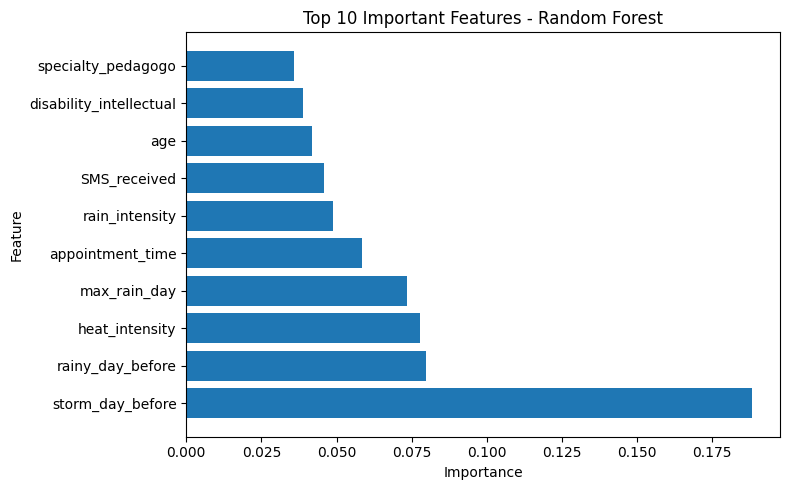

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_smote.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(8,5))
plt.barh(importance['Feature'], importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - Random Forest")
plt.tight_layout()
plt.show()

# 8. CROSS VALIDATION (CV=5)

In [12]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("CV Scores:")
print(cv_scores)

print("\nMean ROC-AUC:")
print(cv_scores.mean())

CV Scores:
[0.75037773 0.75379563 0.75927649 0.75545196 0.75048801]

Mean ROC-AUC:
0.7538779644647853


# Train/Test Validation

In [38]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Train
train_pred = xgb_scaled.predict(X_train_scaled)
train_prob = xgb_scaled.predict_proba(X_train_scaled)[:,1]

print(
    "Train Accuracy:",
    accuracy_score(y_train, train_pred)
)

print(
    "Train ROC-AUC:",
    roc_auc_score(y_train, train_prob)
)

# Test
test_pred = xgb_scaled.predict(X_test_scaled)
test_prob = xgb_scaled.predict_proba(X_test_scaled)[:,1]

print(
    "Test Accuracy:",
    accuracy_score(y_test, test_pred)
)

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, test_prob)
)

Train Accuracy: 0.7152832449084374
Train ROC-AUC: 0.7929185178347802
Test Accuracy: 0.6931818181818182
Test ROC-AUC: 0.7563825025522284


In [13]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    
    # ROC-AUC only if probability exists
    try:
        y_prob = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    except:
        roc = "-"

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision (1)": precision_score(y_test, y_pred, pos_label=1),
        "Precision (0)": precision_score(y_test, y_pred, pos_label=0),

        "Recall (1)": recall_score(y_test, y_pred, pos_label=1),
        "Recall (0)": recall_score(y_test, y_pred, pos_label=0),

        "F1-score (1)": f1_score(y_test, y_pred, pos_label=1),
        "F1-score (0)": f1_score(y_test, y_pred, pos_label=0),

        "ROC-AUC": roc
    }
results = []


# results.append(evaluate_model("Random Forest", rf, X_test, y_test))
# results.append(evaluate_model("Random Forest + Scaling", rf_scaled, X_test_scaled, y_test))
# results.append(evaluate_model("Random Forest + SMOTE", rf_smote, X_test, y_test))
# results.append(evaluate_model("Random ForestScaled + SMOTE", rf_smote, X_test_scaled, y_test))
# results.append(evaluate_model("Random Forest Hyperparameter Tuned", rf_tuned, X_test, y_test))

results.append(evaluate_model("XGBoost", xgb, X_test, y_test))
results.append(evaluate_model("XGBoost + Scaling", xgb_scaled, X_test_scaled, y_test))
results.append(evaluate_model("XGBoost + SMOTE", xgb_smote, X_test, y_test))
results.append(evaluate_model("XGBoostScaled + SMOTE", xgb_smote, X_test_scaled, y_test))


results_df = pd.DataFrame(results)

# Sort by best model (F1-score of class 1)
# results_df = results_df.sort_values(by="F1-score (1)", ascending=False)

results_df

/Users/kaviraj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision (1),Precision (0),Recall (1),Recall (0),F1-score (1),F1-score (0),ROC-AUC
0,XGBoost,0.693182,0.512061,0.840407,0.722845,0.679374,0.599464,0.751359,0.756383
1,XGBoost + Scaling,0.693182,0.512061,0.840407,0.722845,0.679374,0.599464,0.751359,0.756383
2,XGBoost + SMOTE,0.317634,0.317634,0.000000,1.000000,0.000000,0.482128,0.000000,0.515797
3,XGBoostScaled + SMOTE,0.658543,0.477213,0.857143,0.785345,0.599518,0.593679,0.705549,0.751291


XGBoost + Scaling